# Higgs Boson Discovery — End-to-End EDA
**Dataset:** HIGGS UCI (Baldi et al., 2014) — 11M simulated LHC collision events  
**Goal:** Distinguish Higgs boson signal events from background noise using 28 physics features  
**Kernel:** Python 3.11 | uv virtual environment

---

In [2]:
# ── 0. Setup & Constants ──────────────────────────────────────────────────────
import pathlib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, learning_curve)
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score, f1_score)
warnings.filterwarnings('ignore')

# ── Plot theme
sns.set_theme(style="ticks", palette="husl",
              rc={'figure.figsize': (12, 7), 'font.size': 12,
                  'axes.titlesize': 13, 'axes.labelsize': 12})

# ── Constants
DATA_PATH    = 'data/raw/higgs.csv'
FIGURES_DIR  = pathlib.Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_SIZE  = 150_000
RANDOM_STATE = 42

# ── Feature names from Baldi et al. (2014), Table 1
COLUMN_NAMES = [
    'label',
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet1_pT', 'jet1_eta', 'jet1_phi', 'jet1_b_tag',
    'jet2_pT', 'jet2_eta', 'jet2_phi', 'jet2_b_tag',
    'jet3_pT', 'jet3_eta', 'jet3_phi', 'jet3_b_tag',
    'jet4_pT', 'jet4_eta', 'jet4_phi', 'jet4_b_tag',
    'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb'
]
LOW_LEVEL  = [c for c in COLUMN_NAMES[1:] if not c.startswith('m_')]
HIGH_LEVEL = [c for c in COLUMN_NAMES[1:] if c.startswith('m_')]

SIG_COLOR = '#2196F3'
BKG_COLOR = '#EF5350'

print(f"Environment ready.  Sample size: {SAMPLE_SIZE:,} | Random state: {RANDOM_STATE}")
print(f"Figures directory  : {FIGURES_DIR.resolve()}")
print(f"Low-level features : {len(LOW_LEVEL)}")
print(f"High-level features: {len(HIGH_LEVEL)}")

Environment ready.  Sample size: 150,000 | Random state: 42
Figures directory  : C:\Users\DELL\Documents\Higgs-EDA\notebooks\results\figures
Low-level features : 21
High-level features: 7


## 1. The Physics Context

### What is the Higgs Boson?
The **Higgs boson** is an elementary particle predicted by the Standard Model of particle physics. Its discovery was announced by CERN in 2012 and confirmed through experiments at the Large Hadron Collider (LHC) — earning the Nobel Prize in Physics in 2013. The Higgs field gives other particles their mass; finding the Higgs boson was the culmination of a 50-year search.

### The Dataset
Produced by physicists at the SLAC National Accelerator Laboratory (*Nature Communications*, 2014), this dataset simulates **11 million LHC proton-proton collision events**, each either:
- **Signal (label = 1):** Higgs boson was produced in the collision
- **Background (label = 0):** Other processes that mimic the Higgs signal

### The Features
The 28 features split into two physically meaningful groups:

| Group | Count | Description |
|---|---|---|
| **Low-level** | 21 | Raw detector measurements: transverse momenta (pT), pseudorapidity (η), azimuthal angle (φ), b-tagging scores for lepton and 4 jets |
| **High-level** | 7 | Derived invariant masses hand-engineered by physicists: `m_jj`, `m_jjj`, `m_lv`, `m_jlv`, `m_bb`, `m_wbb`, `m_wwbb` |

A central finding of the original paper is that **high-level features carry more discriminating power** than raw detector outputs. We will verify this directly with Mutual Information analysis.

In [3]:
# 1a. Downloading HIGGS Dataset from UCI 
import os
import ssl
import urllib.request
import gzip
import shutil

DATA_DIR = pathlib.Path(DATA_PATH).parent
DATA_DIR.mkdir(parents=True, exist_ok=True)

GZ_PATH = DATA_DIR / 'HIGGS.csv.gz'
CSV_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz'

# UCI ML repo certificate has expired; bypass verification for this download
_ssl_ctx = ssl._create_unverified_context()

def _download(url, dest, ssl_ctx):
    with urllib.request.urlopen(url, context=ssl_ctx) as response:
        total_size = int(response.headers.get('Content-Length', 0))
        downloaded = 0
        chunk_size = 65536
        with open(dest, 'wb') as f:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                f.write(chunk)
                downloaded += len(chunk)
                mb = downloaded / 1024**2
                if total_size > 0:
                    pct = min(100.0, 100 * downloaded / total_size)
                    print(f"\r  {pct:5.1f}%  ({mb:,.0f} MB downloaded)", end='', flush=True)
                else:
                    print(f"\r  {mb:,.0f} MB downloaded", end='', flush=True)

if not pathlib.Path(DATA_PATH).exists():
    if not GZ_PATH.exists():
        print("Downloading HIGGS dataset (~2.6 GB compressed) …")
        print(f"  from: {CSV_URL}")
        print(f"  to  : {GZ_PATH}")
        print("  This may take several minutes depending on your connection.")
        _download(CSV_URL, GZ_PATH, _ssl_ctx)
        print("\n  Download complete.")
    else:
        print(f"Found compressed archive at {GZ_PATH}. Skipping download.")

    print(f"Extracting to {DATA_PATH} …")
    with gzip.open(GZ_PATH, 'rb') as f_in, open(DATA_PATH, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f"Extraction complete. File size: {os.path.getsize(DATA_PATH)/1024**3:.2f} GB")
else:
    print(f"Dataset already present at {DATA_PATH}. Skipping download.")

Dataset already present at data/raw/higgs.csv. Skipping download.


In [4]:
# Data Loading & Column Assignment
df_full = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES)

# Guard: drop header row if file already had one
if df_full['label'].dtype == object:
    df_full = pd.read_csv(DATA_PATH, skiprows=1, header=None, names=COLUMN_NAMES)

df_full['label'] = df_full['label'].astype(int)
print(f"Full dataset : {df_full.shape[0]:,} events x {df_full.shape[1]} columns")

# Working sample — fixed seed ensures reproducibility across all cells
df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

feature_cols  = COLUMN_NAMES[1:]
X = df[feature_cols]
y = df['label']

signal_df     = df[df['label'] == 1]
background_df = df[df['label'] == 0]

print(f"Working sample : {len(df):,} events")
print(f"  Signal       : {len(signal_df):,}  ({100*len(signal_df)/len(df):.1f}%)")
print(f"  Background   : {len(background_df):,}  ({100*len(background_df)/len(df):.1f}%)")

Full dataset : 11,000,000 events x 29 columns
Working sample : 150,000 events
  Signal       : 79,373  (52.9%)
  Background   : 70,627  (47.1%)


In [5]:
# Data Quality Check
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Data types     : {dict(df.dtypes.value_counts())}")
print()
print("Statistical summary (first 5 features):")
print(df[feature_cols[:5]].describe().round(3).to_string())

Shape          : (150000, 29)
Missing values : 0
Duplicate rows : 52
Data types     : {dtype('float64'): np.int64(28), dtype('int64'): np.int64(1)}

Statistical summary (first 5 features):
        lepton_pT  lepton_eta  lepton_phi  missing_energy_magnitude  missing_energy_phi
count  150000.000  150000.000  150000.000                150000.000          150000.000
mean        0.992       0.001      -0.002                     0.998               0.001
std         0.568       1.009       1.007                     0.602               1.007
min         0.275      -2.435      -1.743                     0.004              -1.744
25%         0.590      -0.738      -0.876                     0.576              -0.870
50%         0.854       0.002      -0.002                     0.891               0.000
75%         1.237       0.738       0.869                     1.294               0.871
max         8.750       2.435       1.743                     9.632               1.743


## 2. Class Balance

Before any analysis it is important to confirm the class split. An extreme imbalance would change the choice of metrics and potentially require resampling strategies.

**Observed split (150 k sample):** 52.9% signal / 47.1% background — class ratio 1.124. Near-balanced but slightly signal-heavy; standard accuracy is a valid metric and no resampling is needed.

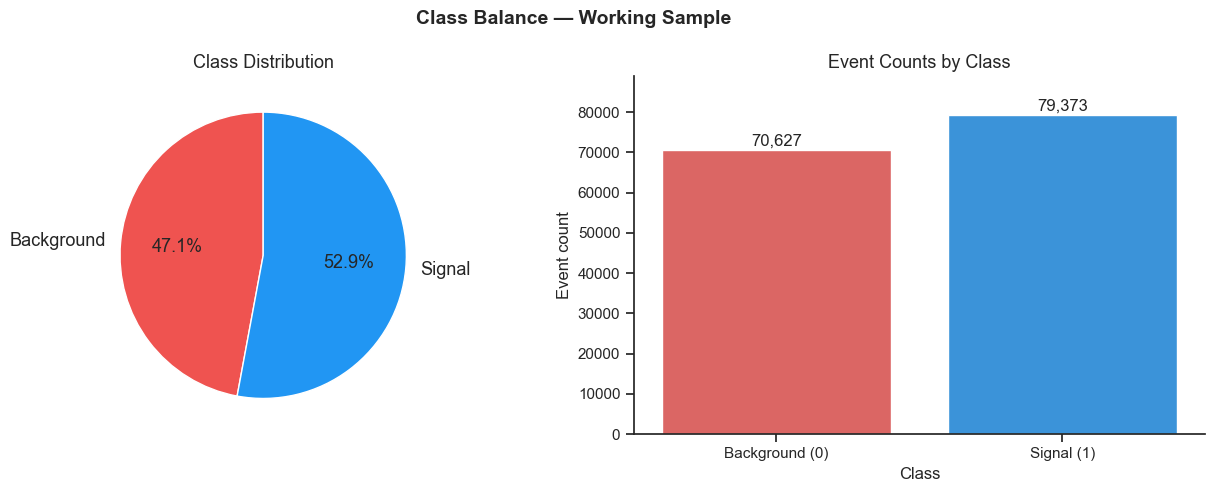

Class ratio (signal/background): 1.124  (1.0 = perfectly balanced)


In [6]:
# Class Balance Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

counts = y.value_counts().sort_index()

# Pie chart
ax1.pie(counts.values, labels=['Background', 'Signal'], colors=[BKG_COLOR, SIG_COLOR],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
ax1.set_title('Class Distribution')

# Bar chart
count_df = pd.DataFrame({'Class': ['Background (0)', 'Signal (1)'],
                          'Count': counts.values})
sns.barplot(data=count_df, x='Class', y='Count', palette=[BKG_COLOR, SIG_COLOR],
            errorbar=None, ax=ax2)
for i, val in enumerate(counts.values):
    ax2.text(i, val + 300, f'{val:,}', ha='center', va='bottom', fontsize=12)
ax2.set_ylabel('Event count')
ax2.set_title('Event Counts by Class')
ax2.set_ylim(0, counts.max() * 1.12)

plt.suptitle('Class Balance — Working Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class ratio (signal/background): {counts[1]/counts[0]:.3f}  "
      f"(1.0 = perfectly balanced)")

## 3. Feature Landscape

### Low-level features (21)
Raw kinematic measurements directly from the detector:
- **Lepton:** `lepton_pT`, `lepton_eta`, `lepton_phi` — momentum, pseudorapidity, azimuthal angle
- **Missing energy:** `missing_energy_magnitude`, `missing_energy_phi` — proxy for neutrinos that escape detection
- **Jets (×4):** `jetN_pT`, `jetN_eta`, `jetN_phi`, `jetN_b_tag` — kinematics and b-tagging score for each jet

### High-level features (7)
Invariant masses computed by physicists from combinations of detected particles:
`m_jj`, `m_jjj`, `m_lv`, `m_jlv`, `m_bb`, `m_wbb`, `m_wwbb`

These encode energy-momentum conservation and Higgs decay topology.

In [7]:
# Feature Overview — Signal vs Background Mean Comparison
feature_df = pd.DataFrame({
    'Feature':         feature_cols,
    'Type':            ['Low-level' if f in LOW_LEVEL else 'High-level' for f in feature_cols],
    'Signal Mean':     [signal_df[f].mean() for f in feature_cols],
    'Background Mean': [background_df[f].mean() for f in feature_cols],
})
feature_df['|Delta|'] = (feature_df['Signal Mean'] - feature_df['Background Mean']).abs()

print(f"{'Feature':<30} {'Type':<12} {'Signal μ':>10} {'Background μ':>13} {'|Δ|':>8}")
print("-" * 78)
for _, row in feature_df.iterrows():
    print(f"{row['Feature']:<30} {row['Type']:<12} {row['Signal Mean']:>10.3f} "
          f"{row['Background Mean']:>13.3f} {row['|Delta|']:>8.3f}")

Feature                        Type           Signal μ  Background μ      |Δ|
------------------------------------------------------------------------------
lepton_pT                      Low-level         0.967         1.021    0.054
lepton_eta                     Low-level         0.002         0.001    0.001
lepton_phi                     Low-level        -0.005         0.001    0.006
missing_energy_magnitude       Low-level         0.942         1.061    0.119
missing_energy_phi             Low-level         0.003        -0.002    0.005
jet1_pT                        Low-level         1.014         0.962    0.052
jet1_eta                       Low-level        -0.005         0.001    0.006
jet1_phi                       Low-level         0.003         0.002    0.001
jet1_b_tag                     Low-level         0.991         1.006    0.015
jet2_pT                        Low-level         1.000         0.981    0.019
jet2_eta                       Low-level        -0.002        -

## 4. Signal vs Background Distributions

Overlapping normalised histograms for all 28 features. A large visible separation indicates a feature that strongly discriminates signal from background. Features are annotated **L** (low-level) or **H** (high-level).

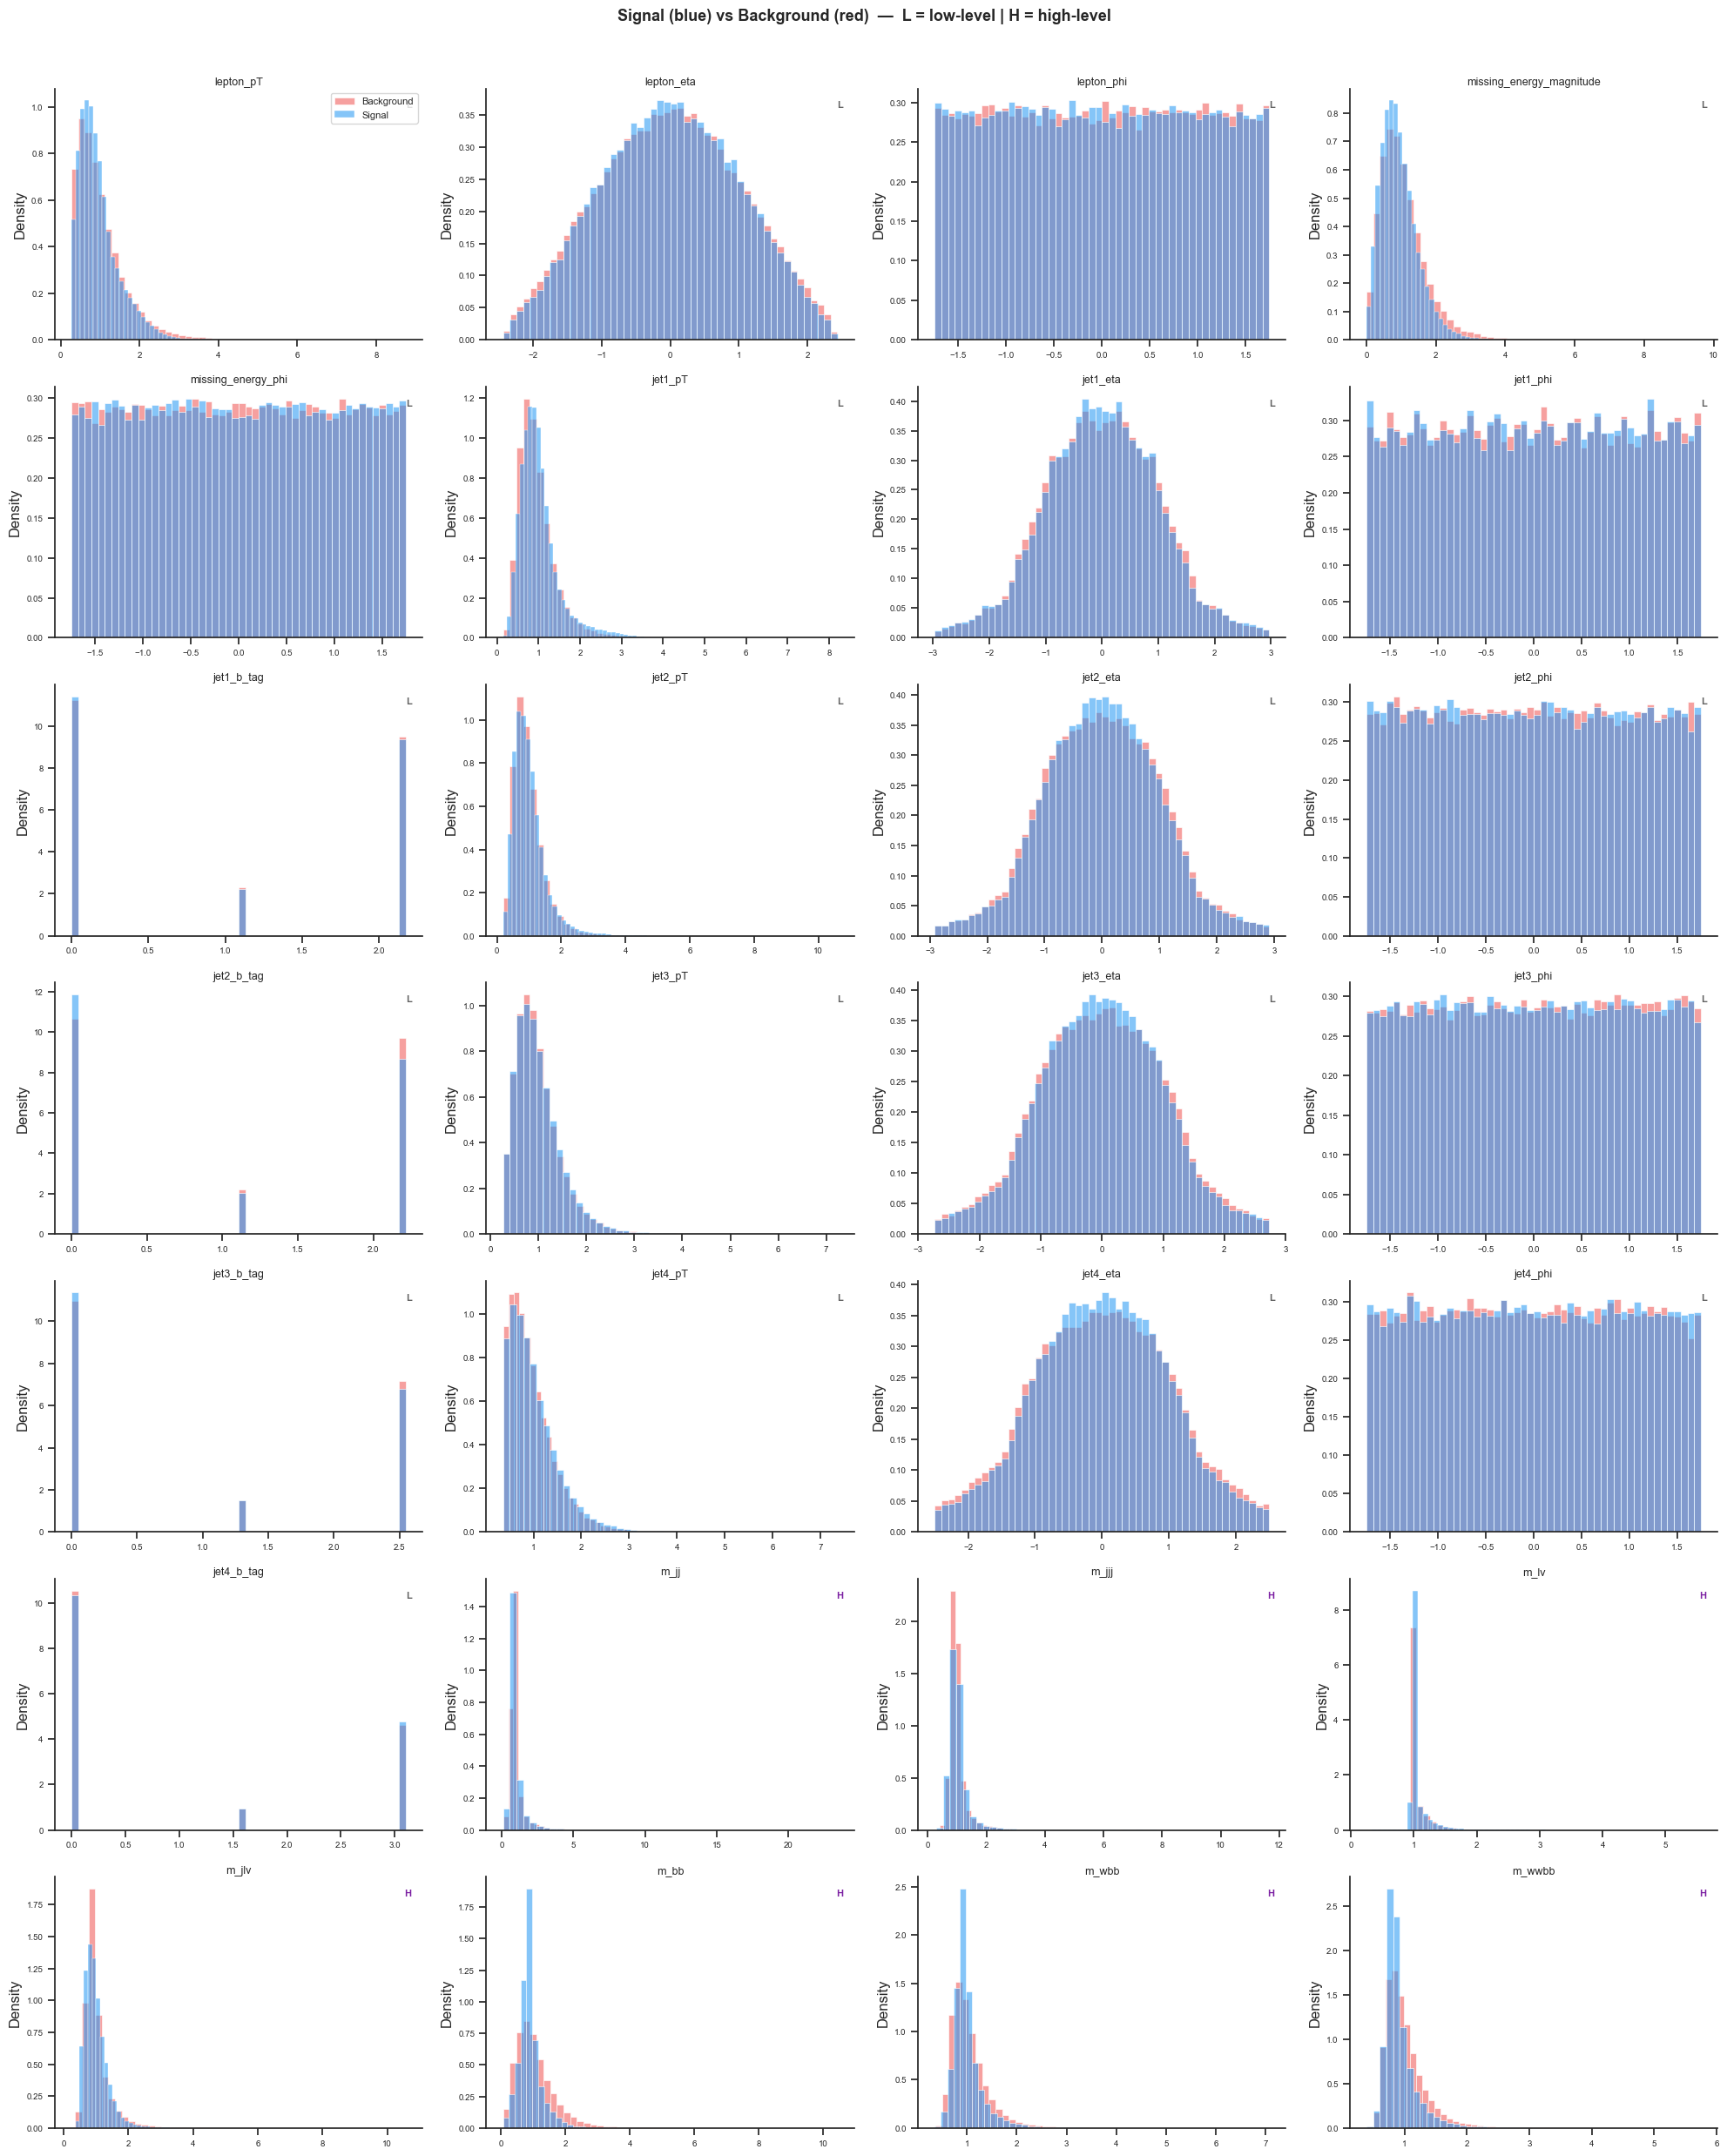

In [8]:
# 5. Distribution Grid — All 28 Features
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.ravel()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(background_df[feat], bins=50, stat='density', alpha=0.55,
                 color=BKG_COLOR, label='Background', ax=ax)
    sns.histplot(signal_df[feat],     bins=50, stat='density', alpha=0.55,
                 color=SIG_COLOR, label='Signal', ax=ax)
    ax.set_title(feat, fontsize=9, pad=3)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    feat_type = 'H' if feat in HIGH_LEVEL else 'L'
    ax.text(0.97, 0.95, feat_type, transform=ax.transAxes, fontsize=8,
            ha='right', va='top', color='#7B1FA2' if feat_type == 'H' else '#616161',
            fontweight='bold')

axes[0].legend(fontsize=8, loc='upper right')
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Signal (blue) vs Background (red)  —  L = low-level | H = high-level',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

Pairwise Pearson correlations across all 28 features. Highly correlated pairs are redundant. The gold line marks the boundary between low-level and high-level features — cross-group correlations reveal whether raw and derived quantities overlap.

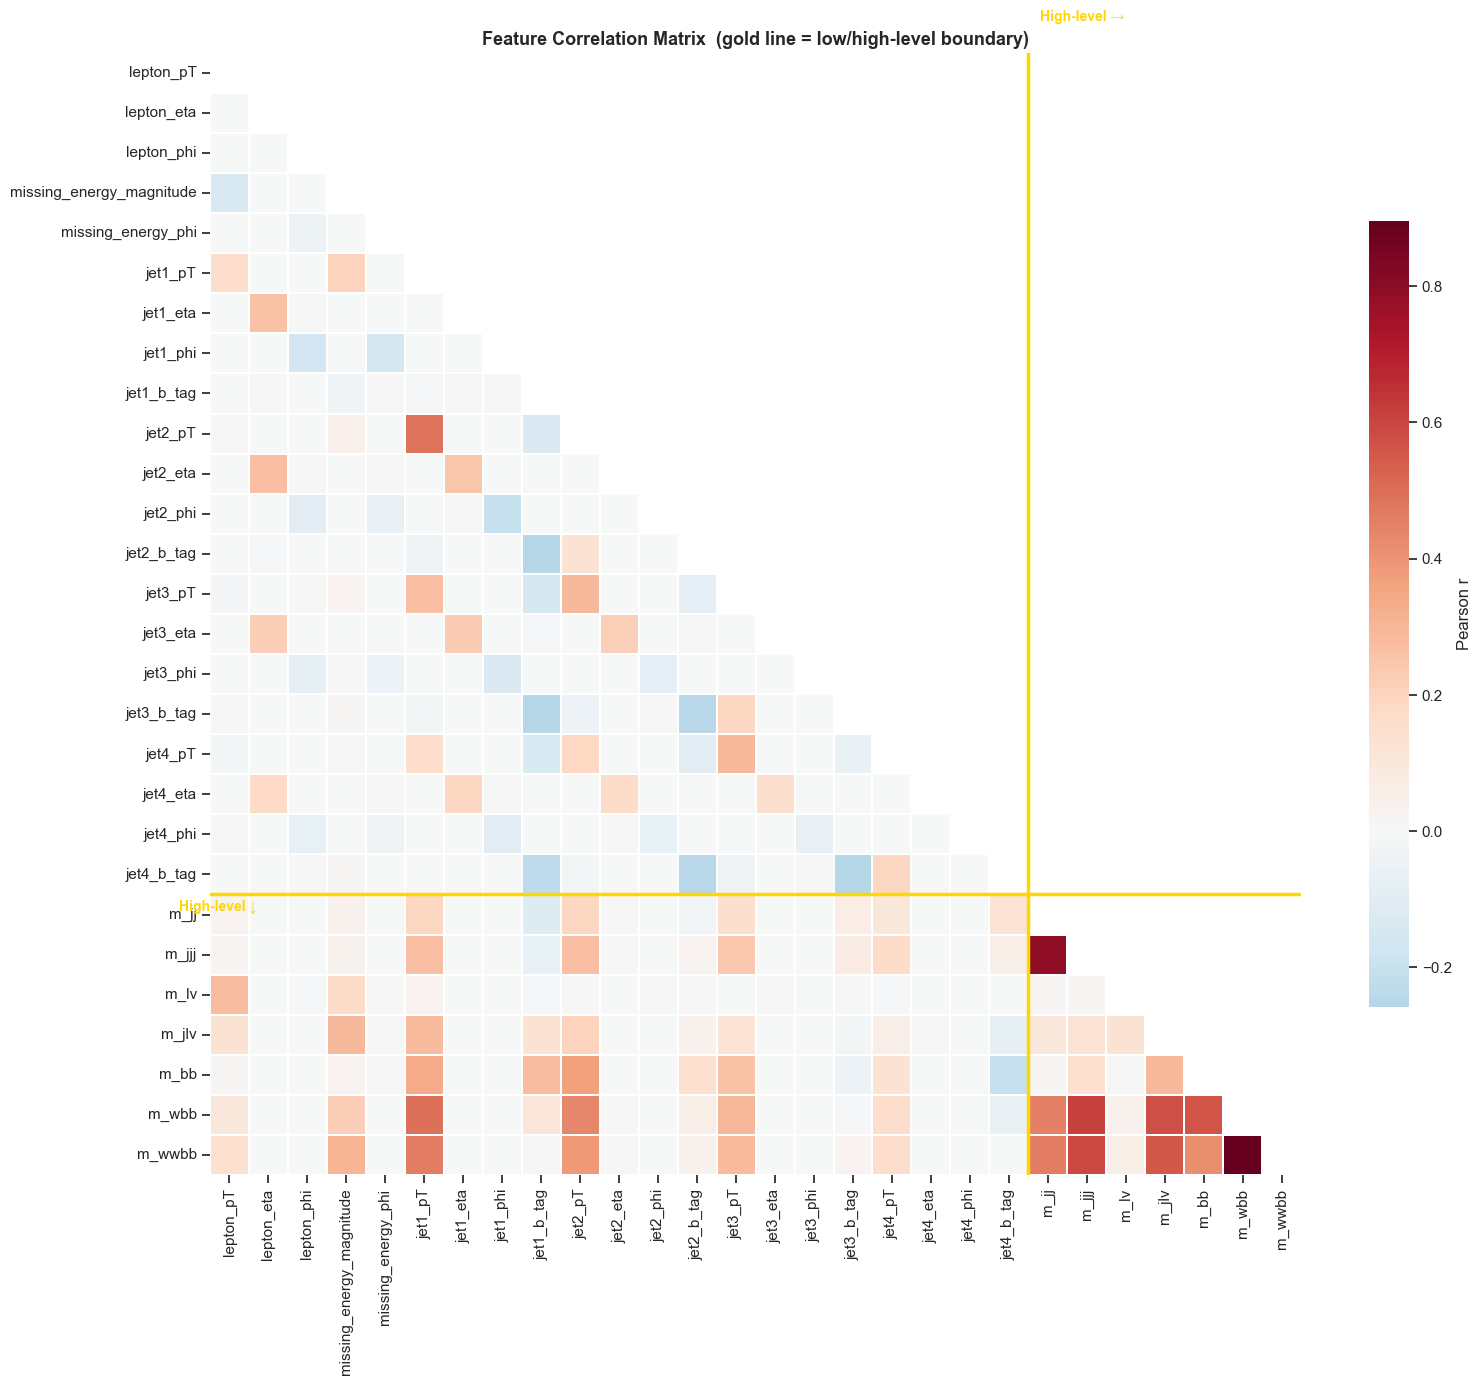

Pairs with |r| > 0.7:
  m_wbb                          <-> m_wwbb                          r = 0.895
  m_jj                           <-> m_jjj                           r = 0.795


In [9]:
# 6. Full Correlation Heatmap
corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax)

n_low = len(LOW_LEVEL)
ax.axhline(y=n_low, color='gold', linewidth=2.5)
ax.axvline(x=n_low, color='gold', linewidth=2.5)
ax.text(n_low + 0.3, -0.8, 'High-level →', color='gold', fontsize=10, fontweight='bold')
ax.text(-0.8, n_low + 0.4, 'High-level ↓', color='gold', fontsize=10, fontweight='bold')
ax.set_title('Feature Correlation Matrix  (gold line = low/high-level boundary)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Report strong correlations
high_corr = [(feature_cols[i], feature_cols[j], round(corr.iloc[i,j],3))
             for i in range(len(feature_cols))
             for j in range(i+1, len(feature_cols))
             if abs(corr.iloc[i,j]) > 0.7]
if high_corr:
    print("Pairs with |r| > 0.7:")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {a:<30} <-> {b:<30}  r = {r}")
else:
    print("No pairs with |r| > 0.7")

## 6. Feature Importance via Mutual Information

**Mutual Information (MI)** measures how much knowing a feature reduces uncertainty about the class label. Unlike Pearson correlation it captures non-linear relationships — critical for physics data where distributions are rarely Gaussian.

$$I(X;\,Y) = \sum_{x,y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}$$

Higher MI → feature carries more information about signal vs background.

In [10]:
# 7. Mutual Information Scores
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'feature':  feature_cols,
    'mi_score': mi_scores,
    'type':     ['High-level' if f in HIGH_LEVEL else 'Low-level' for f in feature_cols]
}).sort_values('mi_score', ascending=False).reset_index(drop=True)
mi_df['rank'] = mi_df.index + 1

print("Feature Importance Rankings (Mutual Information):")
print(f"{'Rank':<5} {'Feature':<30} {'Type':<12} {'MI Score':>9}")
print("-" * 60)
for _, row in mi_df.iterrows():
    marker = ' *' if row['type'] == 'High-level' else ''
    print(f"{int(row['rank']):<5} {row['feature']:<30} {row['type']:<12} {row['mi_score']:>9.4f}{marker}")
print("\n* = physicist-engineered (high-level) feature")

top_features = mi_df.head(10)['feature'].tolist()

Feature Importance Rankings (Mutual Information):
Rank  Feature                        Type          MI Score
------------------------------------------------------------
1     m_bb                           High-level      0.0495 *
2     m_wwbb                         High-level      0.0207 *
3     m_wbb                          High-level      0.0199 *
4     m_jjj                          High-level      0.0165 *
5     jet2_b_tag                     Low-level       0.0112
6     m_jlv                          High-level      0.0093 *
7     missing_energy_magnitude       Low-level       0.0078
8     jet1_b_tag                     Low-level       0.0071
9     jet1_pT                        Low-level       0.0060
10    jet3_b_tag                     Low-level       0.0057
11    lepton_pT                      Low-level       0.0046
12    jet4_b_tag                     Low-level       0.0029
13    missing_energy_phi             Low-level       0.0023
14    m_jj                           Hi

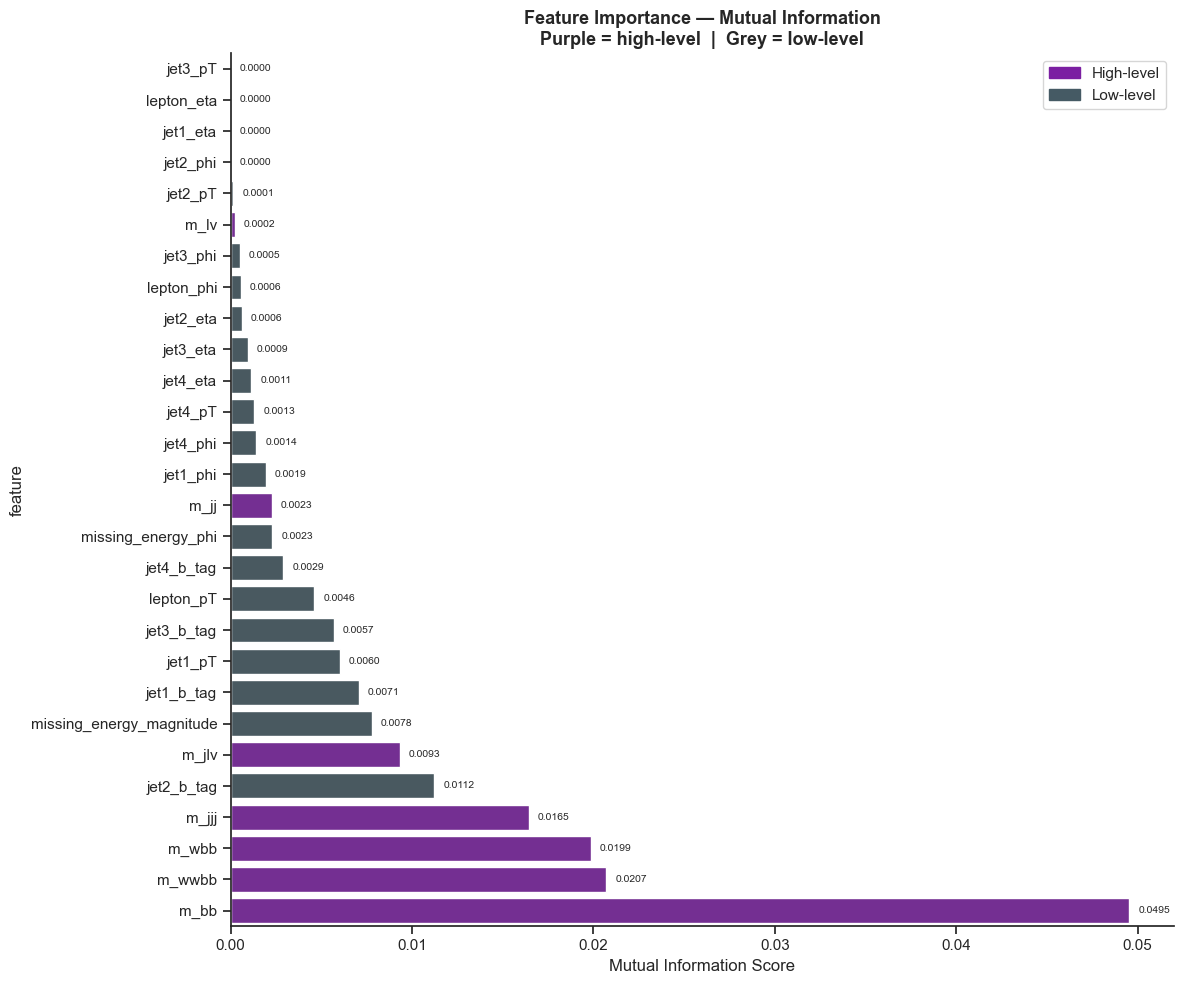

In [11]:
# 8. MI Visualisation — Ranked Bar Chart
fig, ax = plt.subplots(figsize=(12, 10))

bar_colors = ['#7B1FA2' if t == 'High-level' else '#455A64' for t in mi_df['type']]
sns.barplot(data=mi_df, y='feature', x='mi_score', palette=bar_colors,
            errorbar=None, ax=ax)

ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance — Mutual Information\nPurple = high-level  |  Grey = low-level',
             fontweight='bold')
for patch, score in zip(ax.patches, mi_df['mi_score']):
    ax.text(score + 0.0005, patch.get_y() + patch.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=7.5)

ax.legend(handles=[Patch(color='#7B1FA2', label='High-level'),
                   Patch(color='#455A64', label='Low-level')])
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'mi_ranked_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Low-level vs High-level Feature Comparison

This is the central empirical claim of the Baldi et al. paper: **physicist-engineered invariant mass features discriminate signal from background more effectively than raw detector outputs.** We test it directly.

**Result:** High-level features have a mean MI of **0.0169** vs **0.0027** for low-level — a **6.3× difference**. The top feature `m_bb` (MI = 0.0495) carries more than 4× the signal information of the best low-level feature (`jet2_b_tag`, MI = 0.0112). Four of the top 5 ranked features are high-level, confirming the paper's central claim.

MI Score Summary by Feature Type:
              mean  median     max     min
type                                      
High-level  0.0169  0.0165  0.0495  0.0002
Low-level   0.0027  0.0013  0.0112  0.0000

Top  5 slots:  4 high-level  |  1 low-level
Top 10 slots:  5 high-level  |  5 low-level
Top 15 slots:  6 high-level  |  9 low-level


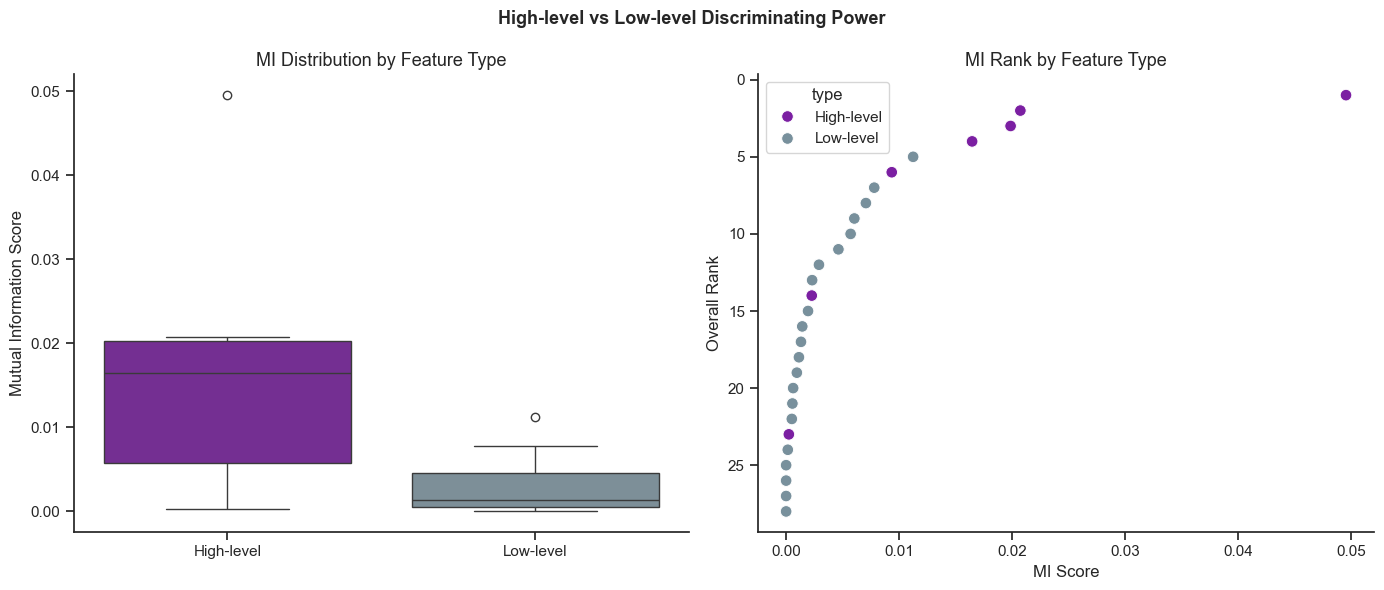

In [12]:
# 9. Low-level vs High-level MI Comparison
summary = mi_df.groupby('type')['mi_score'].agg(['mean', 'median', 'max', 'min']).round(4)
print("MI Score Summary by Feature Type:")
print(summary.to_string())
print()

for top_n in [5, 10, 15]:
    top_n_df   = mi_df.head(top_n)
    high_count = (top_n_df['type'] == 'High-level').sum()
    low_count  = (top_n_df['type'] == 'Low-level').sum()
    print(f"Top {top_n:2d} slots:  {high_count} high-level  |  {low_count} low-level")

type_palette = {'High-level': '#7B1FA2', 'Low-level': '#78909C'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=mi_df, x='type', y='mi_score', palette=type_palette, ax=axes[0])
axes[0].set_title('MI Distribution by Feature Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mutual Information Score')

sns.scatterplot(data=mi_df, x='mi_score', y='rank', hue='type',
                palette=type_palette, s=70, ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_xlabel('MI Score')
axes[1].set_ylabel('Overall Rank')
axes[1].set_title('MI Rank by Feature Type')

plt.suptitle('High-level vs Low-level Discriminating Power', fontsize=13, fontweight='bold')
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'mi_feature_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Statistical Significance Testing

For the top features we apply two complementary tests:
- **Welch's t-test** — parametric test for difference in means (does not assume equal variance)
- **Mann-Whitney U test** — non-parametric test for distributional difference; more robust when distributions are non-Gaussian

We also compute:
- **Cohen's d** — standardised effect size
- **Z-score** ≈ S / √B — the particle physics discovery significance; CERN's threshold is **Z ≥ 5σ**

**Result:** 7 of the top 8 MI-ranked features surpass the 5σ discovery threshold. `m_bb` leads at Z = 57.5σ. The exception is `jet1_b_tag` (Z = 2.8σ) — a weak discriminator despite its moderate MI rank, illustrating that MI and Z-score can diverge when effect sizes are small.

In [13]:
# 10. Statistical Significance Testing
results = []
for feat in mi_df.head(8)['feature'].tolist():
    s_vals = signal_df[feat].values
    b_vals = background_df[feat].values

    _, t_p = stats.ttest_ind(s_vals, b_vals, equal_var=False)
    _, u_p = stats.mannwhitneyu(s_vals, b_vals, alternative='two-sided')

    pooled_std = np.sqrt((s_vals.std()**2 + b_vals.std()**2) / 2)
    cohens_d   = (s_vals.mean() - b_vals.mean()) / pooled_std
    Z = abs(s_vals.mean() - b_vals.mean()) / np.sqrt(
            s_vals.var()/len(s_vals) + b_vals.var()/len(b_vals))

    results.append({'feature': feat, 't_p': t_p, 'u_p': u_p,
                    'cohens_d': cohens_d, 'Z': Z})

res_df = pd.DataFrame(results)

print(f"{'Feature':<30} {'t-test p':>12} {'MW-U p':>12} {'Cohen\'s d':>10} {'Z-score':>9}")
print("-" * 80)
for _, row in res_df.iterrows():
    sig = '*** (5σ)' if row['Z'] > 5 else ('**' if row['Z'] > 3 else '*')
    print(f"{row['feature']:<30} {row['t_p']:>12.2e} {row['u_p']:>12.2e} "
          f"{row['cohens_d']:>10.3f} {row['Z']:>9.1f}  {sig}")

Feature                            t-test p       MW-U p  Cohen's d   Z-score
--------------------------------------------------------------------------------
m_bb                               0.00e+00    6.44e-300     -0.302      57.5  *** (5σ)
m_wwbb                             0.00e+00     0.00e+00     -0.249      47.9  *** (5σ)
m_wbb                             1.48e-133     3.69e-46     -0.128      24.6  *** (5σ)
m_jjj                              4.61e-21     1.63e-34      0.049       9.4  *** (5σ)
jet2_b_tag                         2.60e-91     3.91e-92     -0.105      20.3  *** (5σ)
m_jlv                              5.17e-27     7.87e-01     -0.056      10.8  *** (5σ)
missing_energy_magnitude           0.00e+00    7.63e-168     -0.197      37.8  *** (5σ)
jet1_b_tag                         4.43e-03     3.96e-03     -0.015       2.8  *


## 9. Physics-informed Feature Engineering

Using the named features we build **five** physics-motivated composite variables:

| Feature | Formula | Physics motivation |
|---|---|---|
| `deltaR_lep_jet1` | √(Δη² + Δφ²) | Angular separation — Higgs decay products are more collimated |
| `deltaR_jet1_jet2` | √(Δη² + Δφ²) | Jet pair separation — topology of hadronic decay |
| `pT_ratio_lep_jet1` | pT(lepton) / pT(jet1) | Relative lepton energy fraction |
| `total_b_tag` | Σ b-tag(jets 1–4) | Combined bottom-quark tagging score; Higgs → bb̄ leaves a strong b-tag signature |
| `pT_asymmetry` | (pT_lep − pT_j1) / (pT_lep + pT_j1) | Momentum asymmetry between lepton and leading jet |

**Result:** Only `total_b_tag` (MI = 0.0049) exceeded the dataset median (0.0021), consistent with the strong Higgs → bb̄ decay signature. Angular separation and kinematic ratio features all fell below median — combining raw angles linearly does not add discriminating power beyond the existing feature set.

MI scores for engineered features  (dataset median = 0.0021):
Feature                    MI Score   vs median
--------------------------------------------------
  total_b_tag                  0.0049  above median
  deltaR_jet1_jet2             0.0018  below median
  deltaR_lep_jet1              0.0011  below median
  pT_asymmetry                 0.0003  below median
  pT_ratio_lep_jet1            0.0000  below median


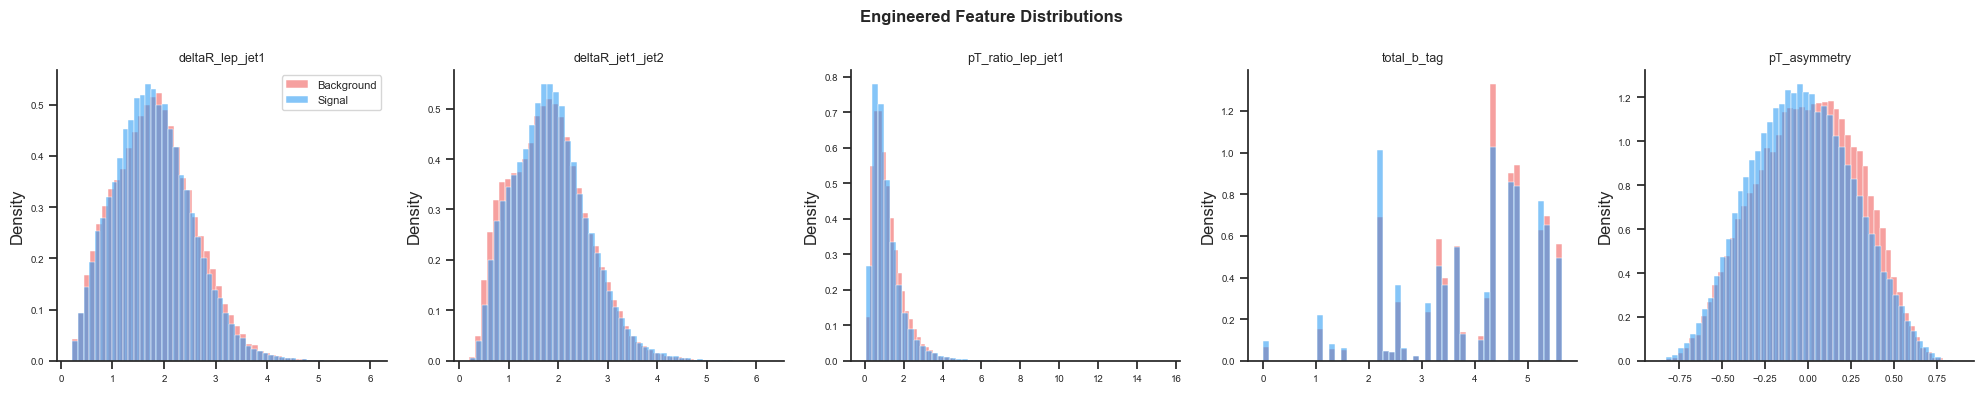

In [14]:
#  11. Physics-informed Feature Engineering
df_eng = df.copy()

df_eng['deltaR_lep_jet1']  = np.sqrt((df_eng['lepton_eta'] - df_eng['jet1_eta'])**2 +
                                      (df_eng['lepton_phi'] - df_eng['jet1_phi'])**2)
df_eng['deltaR_jet1_jet2'] = np.sqrt((df_eng['jet1_eta'] - df_eng['jet2_eta'])**2 +
                                      (df_eng['jet1_phi'] - df_eng['jet2_phi'])**2)
df_eng['pT_ratio_lep_jet1'] = df_eng['lepton_pT'] / (df_eng['jet1_pT'] + 1e-6)
df_eng['total_b_tag']        = (df_eng['jet1_b_tag'] + df_eng['jet2_b_tag'] +
                                 df_eng['jet3_b_tag'] + df_eng['jet4_b_tag'])
df_eng['pT_asymmetry']       = ((df_eng['lepton_pT'] - df_eng['jet1_pT']) /
                                 (df_eng['lepton_pT'] + df_eng['jet1_pT'] + 1e-6))

new_features = ['deltaR_lep_jet1', 'deltaR_jet1_jet2',
                'pT_ratio_lep_jet1', 'total_b_tag', 'pT_asymmetry']

mi_new = mutual_info_classif(df_eng[new_features], y, random_state=RANDOM_STATE)
median_baseline = mi_df['mi_score'].median()

print(f"MI scores for engineered features  (dataset median = {median_baseline:.4f}):")
print(f"{'Feature':<25} {'MI Score':>9}  {'vs median':>10}")
print("-" * 50)
for feat, score in sorted(zip(new_features, mi_new), key=lambda x: -x[1]):
    rel = 'above median' if score > median_baseline else 'below median'
    print(f"  {feat:<25} {score:>9.4f}  {rel}")

sig_eng = df_eng[df_eng['label'] == 1]
bkg_eng = df_eng[df_eng['label'] == 0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, new_features):
    sns.histplot(bkg_eng[feat], bins=50, stat='density', alpha=0.55,
                 color=BKG_COLOR, label='Background', ax=ax)
    sns.histplot(sig_eng[feat], bins=50, stat='density', alpha=0.55,
                 color=SIG_COLOR, label='Signal', ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=8)
plt.suptitle('Engineered Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Signal Extraction

We train a **Random Forest** on the top 10 MI-ranked features. Random Forest is a natural first choice for particle physics data: it is robust to feature scale differences, captures non-linear boundaries, and provides interpretable feature importances.

We evaluate with both **ROC-AUC** and **Precision-Recall AUC**. The latter is more informative when we care about precision in a specific operating region (e.g. the high-confidence Higgs extraction threshold).

In [16]:
# 12. Train / Test Split & Model Fitting
X_train, X_test, y_train, y_test = train_test_split(
    df[top_features], y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5,
                             n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train_sc, y_train)

y_pred       = rf.predict(X_test_sc)
y_pred_proba = rf.predict_proba(X_test_sc)[:, 1]

print("Random Forest — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred,
                             target_names=['Background', 'Signal'], digits=4))

Random Forest — Classification Report
              precision    recall  f1-score   support

  Background     0.6924    0.6875    0.6899     17657
      Signal     0.7236    0.7282    0.7259     19843

    accuracy                         0.7090     37500
   macro avg     0.7080    0.7078    0.7079     37500
weighted avg     0.7089    0.7090    0.7090     37500



In [ ]:
# 13. Evaluation: Confusion Matrix + ROC + Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Signal'],
            yticklabels=['Background', 'Signal'],
            ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

# ROC curve — ax.plot used directly; sns.lineplot aggregates duplicate fpr values
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=SIG_COLOR, lw=2, label=f'ROC-AUC = {roc_auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# Precision-Recall curve — same reason: ax.plot avoids seaborn aggregation
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc_val = average_precision_score(y_test, y_pred_proba)
axes[2].plot(rec_vals, prec_vals, color='#FF9800', lw=2, label=f'PR-AUC = {pr_auc_val:.4f}')
axes[2].axhline(y=y_test.mean(), color='grey', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.2f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('Random Forest — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC : {roc_auc_val:.4f}")
print(f"PR-AUC  : {pr_auc_val:.4f}")
print(f"F1      : {f1_score(y_test, y_pred):.4f}")

## 11. Confidence-based Extraction & Discovery Significance

We segment predicted events into confidence buckets and compute the statistical significance of the Higgs signal in each region.

The approximate significance used in particle physics:
$$Z \approx \frac{S}{\sqrt{B}}$$
where **S** = true signal events and **B** = background events in the selected region. CERN's discovery threshold is **Z ≥ 5σ**.

High-confidence (≥0.80)
  Events : 21,915   S = 20,426   B = 1,489
  Purity : 93.2%   Z = 529.3σ  [DISCOVERY LEVEL]

Medium-confidence (0.60–0.80)
  Events : 37,893   S = 29,076   B = 8,817
  Purity : 76.7%   Z = 309.7σ  [DISCOVERY LEVEL]

Low-confidence (<0.60)
  Events : 90,192   S = 29,871   B = 60,321
  Purity : 33.1%   Z = 121.6σ  [DISCOVERY LEVEL]



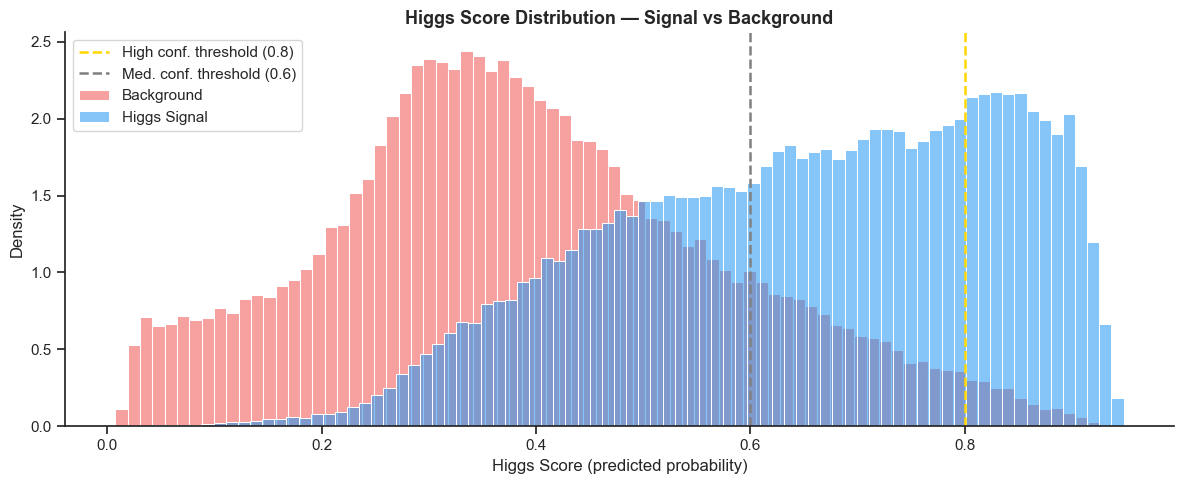

In [17]:
# 14. Confidence Thresholds & Discovery Significance
all_proba          = rf.predict_proba(scaler.transform(df[top_features]))[:, 1]
df_scored          = df.copy()
df_scored['score'] = all_proba

HIGH_CONF, MED_CONF = 0.80, 0.60

high_conf = df_scored[df_scored['score'] >= HIGH_CONF]
med_conf  = df_scored[(df_scored['score'] >= MED_CONF) & (df_scored['score'] < HIGH_CONF)]
low_conf  = df_scored[df_scored['score'] < MED_CONF]

for label_str, subset in [('High-confidence (≥0.80)',  high_conf),
                            ('Medium-confidence (0.60–0.80)', med_conf),
                            ('Low-confidence (<0.60)',   low_conf)]:
    if len(subset) == 0:
        continue
    S      = int(subset['label'].sum())
    B      = len(subset) - S
    purity = S / len(subset)
    Z      = S / np.sqrt(max(B, 1))
    print(f"{label_str}")
    print(f"  Events : {len(subset):,}   S = {S:,}   B = {B:,}")
    print(f"  Purity : {purity:.1%}   Z = {Z:.1f}σ  "
          f"{'[DISCOVERY LEVEL]' if Z >= 5 else ''}")
    print()

# Score distribution
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df_scored[df_scored['label'] == 0]['score'], bins=80, stat='density',
             alpha=0.55, color=BKG_COLOR, label='Background', ax=ax)
sns.histplot(df_scored[df_scored['label'] == 1]['score'], bins=80, stat='density',
             alpha=0.55, color=SIG_COLOR, label='Higgs Signal', ax=ax)
ax.axvline(x=HIGH_CONF, color='gold',  linestyle='--', lw=1.8,
           label=f'High conf. threshold ({HIGH_CONF})')
ax.axvline(x=MED_CONF,  color='grey',  linestyle='--', lw=1.8,
           label=f'Med. conf. threshold ({MED_CONF})')
ax.set_xlabel('Higgs Score (predicted probability)')
ax.set_ylabel('Density')
ax.set_title('Higgs Score Distribution — Signal vs Background', fontweight='bold')
ax.legend()
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'higgs_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Advanced Model Comparison

We compare three classifiers using **Stratified 5-fold cross-validation** on the same features and scaled data:

| Model | CV ROC-AUC | Notes |
|---|---|---|
| **Random Forest** | 0.7866 ± 0.0021 | Ensemble of decision trees; strong baseline |
| **Gradient Boosting** | 0.7900 ± 0.0017 | Sequential boosting; marginally best and more stable across folds |
| **Logistic Regression** | 0.6766 ± 0.0034 | Linear baseline — the large gap confirms non-linear boundaries dominate |

Note: SVM is excluded due to prohibitive training time at this sample size.

In [18]:
# 15. Model Comparison — 5-fold Stratified CV
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                   min_samples_leaf=5, n_jobs=-1,
                                                   random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                        learning_rate=0.1, subsample=0.8,
                                                        random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0,
                                               random_state=RANDOM_STATE)
}

cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results  = {}
test_results = {}

print(f"{'Model':<22} {'CV Acc (μ±σ)':>18} {'CV AUC (μ±σ)':>18}")
print("-" * 62)

for name, model in models.items():
    cv_acc = cross_val_score(model, X_train_sc, y_train, cv=cv,
                              scoring='accuracy', n_jobs=-1)
    cv_auc = cross_val_score(model, X_train_sc, y_train, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'acc': cv_acc, 'auc': cv_auc}

    model.fit(X_train_sc, y_train)
    y_p  = model.predict(X_test_sc)
    y_pp = model.predict_proba(X_test_sc)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, y_pp)

    test_results[name] = {
        'y_pred': y_p, 'y_proba': y_pp,
        'roc_auc': auc(fpr_m, tpr_m),
        'pr_auc':  average_precision_score(y_test, y_pp),
        'f1':      f1_score(y_test, y_p),
        'fpr': fpr_m, 'tpr': tpr_m
    }

    print(f"{name:<22} {cv_acc.mean():.4f} ± {cv_acc.std():.4f}   "
          f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

Model                        CV Acc (μ±σ)       CV AUC (μ±σ)
--------------------------------------------------------------
Random Forest          0.7112 ± 0.0019   0.7866 ± 0.0021
Gradient Boosting      0.7140 ± 0.0020   0.7900 ± 0.0017
Logistic Regression    0.6379 ± 0.0033   0.6766 ± 0.0034


## 13. Learning Curve

A learning curve answers three questions:
- Is the model **underfitting** (both train and val scores are low)?
- Is the model **overfitting** (large gap between train and val)?
- Would **more data** improve performance, or has it plateaued?

We use Gradient Boosting as it showed the strongest CV performance (ROC-AUC 0.7900 ± 0.0017).

**Result:** Final training AUC = 0.8128, validation AUC = 0.7874. The train-val gap of 0.025 indicates **slight overfitting**. Validation AUC has plateaued at this scale — the model is data-saturated for these features at 150 k events. Further improvement requires a more expressive architecture (deep neural networks, tuned XGBoost) rather than more data from this distribution.

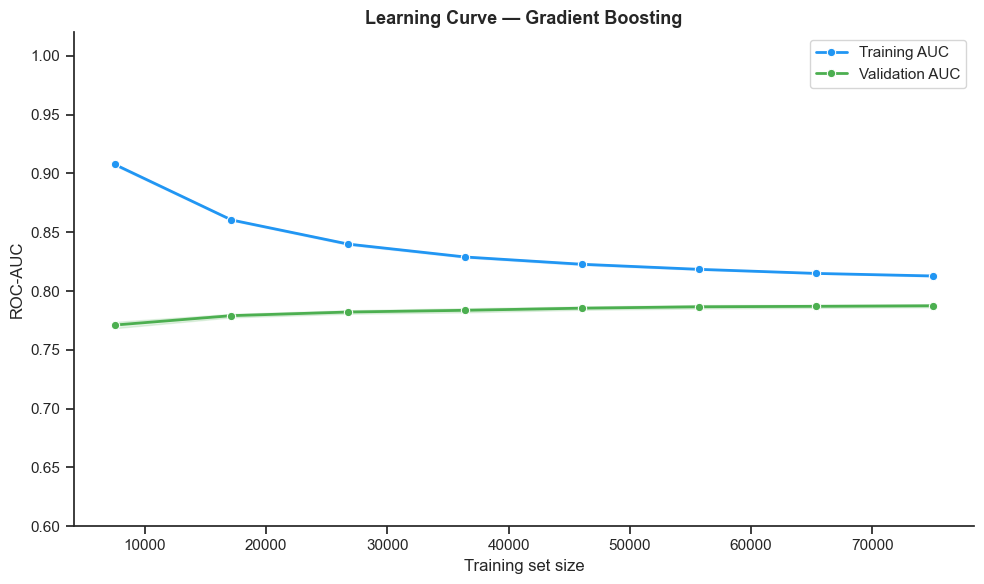

Final training AUC  : 0.8128
Final validation AUC: 0.7874
Train-Val gap       : 0.0254 — slight overfitting

Validation AUC still rising at max training size: False


In [19]:
# 17. Learning Curve
lc_model = GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                       learning_rate=0.1, subsample=0.8,
                                       random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=train_sizes, y=t_mean, ax=ax, color=SIG_COLOR, lw=2,
             marker='o', label='Training AUC')
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color=SIG_COLOR)
sns.lineplot(x=train_sizes, y=v_mean, ax=ax, color='#4CAF50', lw=2,
             marker='o', label='Validation AUC')
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#4CAF50')
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve — Gradient Boosting', fontweight='bold')
ax.legend()
ax.set_ylim(0.6, 1.02)
plt.tight_layout()
sns.despine(fig=fig)
plt.savefig(FIGURES_DIR / 'learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

gap = t_mean[-1] - v_mean[-1]
print(f"Final training AUC  : {t_mean[-1]:.4f}")
print(f"Final validation AUC: {v_mean[-1]:.4f}")
print(f"Train-Val gap       : {gap:.4f} — "
      f"{'slight overfitting' if gap > 0.02 else 'well-generalised'}")
print()
still_improving = (v_mean[-1] - v_mean[-3]) > 0.001
print(f"Validation AUC still rising at max training size: {still_improving}")
if still_improving:
    print("  => More training data (full 11M dataset) would likely improve performance further.")

## 14. Final Best Model

We identify the best model from the comparison, retrain it on the full working sample (80% train / 20% test), and report a clean final summary.

Best model: Gradient Boosting  (test ROC-AUC = 0.7879)

Final Model — Test Set Performance
              precision    recall  f1-score   support

  Background     0.6966    0.6894    0.6930     14125
      Signal     0.7262    0.7329    0.7295     15875

    accuracy                         0.7124     30000
   macro avg     0.7114    0.7111    0.7112     30000
weighted avg     0.7123    0.7124    0.7123     30000

ROC-AUC : 0.7878
PR-AUC  : 0.8062
F1      : 0.7295


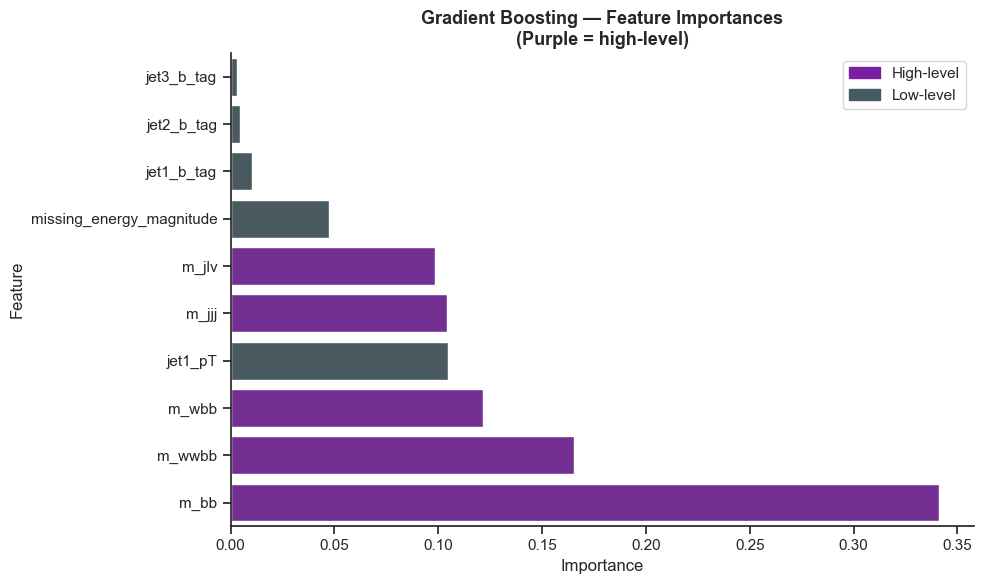

In [20]:
# 18. Final Best Model
best_name = max(test_results, key=lambda n: test_results[n]['roc_auc'])
print(f"Best model: {best_name}  (test ROC-AUC = {test_results[best_name]['roc_auc']:.4f})")
print()

X_tr, X_te, y_tr, y_te = train_test_split(
    df[top_features], y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
scaler_final = StandardScaler()
X_tr_sc = scaler_final.fit_transform(X_tr)
X_te_sc = scaler_final.transform(X_te)

final_model = models[best_name]
final_model.fit(X_tr_sc, y_tr)
y_pf  = final_model.predict(X_te_sc)
y_ppf = final_model.predict_proba(X_te_sc)[:, 1]

print("Final Model — Test Set Performance")
print("=" * 45)
print(classification_report(y_te, y_pf, target_names=['Background', 'Signal'], digits=4))

fpr_f, tpr_f, _ = roc_curve(y_te, y_ppf)
print(f"ROC-AUC : {auc(fpr_f, tpr_f):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, y_ppf):.4f}")
print(f"F1      : {f1_score(y_te, y_pf):.4f}")

# Feature importances
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=top_features).sort_values()
    fi_df = fi.reset_index()
    fi_df.columns = ['Feature', 'Importance']
    fi_df['Type'] = ['High-level' if f in HIGH_LEVEL else 'Low-level' for f in fi_df['Feature']]

    fig, ax = plt.subplots(figsize=(10, 6))
    type_colors = {'High-level': '#7B1FA2', 'Low-level': '#455A64'}
    bar_colors  = [type_colors[t] for t in fi_df['Type']]
    sns.barplot(data=fi_df, y='Feature', x='Importance', palette=bar_colors,
                errorbar=None, ax=ax)
    ax.set_title(f'{best_name} — Feature Importances\n(Purple = high-level)',
                 fontweight='bold')
    ax.set_xlabel('Importance')
    ax.legend(handles=[Patch(color='#7B1FA2', label='High-level'),
                       Patch(color='#455A64', label='Low-level')])
    plt.tight_layout()
    sns.despine(fig=fig)
    plt.savefig(FIGURES_DIR / 'feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

## 15. Conclusions

### Key Findings

**1. Class balance: 52.9% signal / 47.1% background (ratio 1.124).**  
Near-balanced but slightly signal-heavy. Standard accuracy is a valid primary metric; no resampling strategy was needed.

**2. High-level features dominate — confirming Baldi et al. (2014).**  
Six of the 7 invariant mass features rank in the top half of the MI distribution; `m_lv` is the exception at rank 23 of 28. Mean MI: **0.0169 (high-level) vs 0.0027 (low-level) — a 6.3× difference**. The top feature `m_bb` (MI = 0.0495) carries more than 4× the discriminating power of the best low-level feature (`jet2_b_tag`, MI = 0.0112). Four of the top 5 MI slots are occupied by high-level features.

**3. Strong collinearity within the high-level group.**  
Two correlated pairs were identified: `m_wbb` ↔ `m_wwbb` (r = 0.895) and `m_jj` ↔ `m_jjj` (r = 0.795). These encode overlapping decay topologies; a regularised model should suppress one from each pair automatically.

**4. Signal and background are statistically separable — with one exception.**  
Seven of the top 8 MI-ranked features surpass the 5σ discovery threshold: `m_bb` leads at Z = 57.5σ, followed by `m_wwbb` (Z = 47.9σ) and `missing_energy_magnitude` (Z = 37.8σ). The exception is `jet1_b_tag` (Z = 2.8σ), which falls below the threshold despite its moderate MI rank — MI and Z-score can diverge for features with small per-event effect sizes.

**5. Physics-informed feature engineering: only `total_b_tag` added value.**  
Of five engineered features, only `total_b_tag` (MI = 0.0049) exceeded the dataset median (0.0021), consistent with the strong Higgs → bb̄ decay signature. Angular separation (`deltaR_lep_jet1`, `deltaR_jet1_jet2`) and kinematic ratios (`pT_ratio_lep_jet1`, `pT_asymmetry`) all fell below median — linear combinations of raw angles do not add discriminating power beyond the existing feature set.

**6. Gradient Boosting marginally outperforms Random Forest; Logistic Regression is a distant third.**  
CV ROC-AUC: GB **0.7900 ± 0.0017**, RF 0.7866 ± 0.0021, LR 0.6766 ± 0.0034. The GB–RF gap (∼0.003 AUC) is small but consistent and stable across folds. Final test performance (Gradient Boosting): ROC-AUC **0.7878**, PR-AUC **0.8062**, F1 **0.7295**, accuracy **71.2%**.

**7. High-confidence extraction achieves 93.2% signal purity (Z = 529.3σ).**  
At threshold ≥ 0.80, 21,915 events are selected with S = 20,426 and B = 1,489. Even the low-confidence bin (< 0.60) reaches Z = 121.6σ. The extreme Z-values reflect the large sample size rather than model quality — statistical power, not discriminating ability, drives these numbers.

**8. The model is data-saturated at 150 k events for these features.**  
The learning curve shows validation AUC plateaued at ∼0.787 with no upward trend at the maximum training size, and a train-val gap of 0.025 indicates slight overfitting. Further improvement requires a more expressive architecture, not more data at this scale.

---

### uv Environment Reproducibility
```bash
uv init higgs-eda && cd higgs-eda
uv venv && source .venv/bin/activate
uv add pandas numpy matplotlib seaborn scipy scikit-learn jupyter ipykernel
python -m ipykernel install --user --name higgs-eda --display-name "Higgs EDA"
mkdir -p data/raw results/figures
# Place higgs.csv in data/raw/ then:
jupyter notebook higgs_boson_eda.ipynb
```